In [48]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import napari
from skimage.transform import radon, rescale
from skimage.transform import iradon, iradon_sart


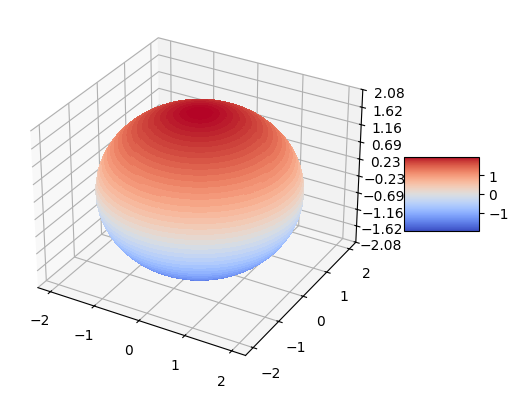

In [ ]:
# R value is radius of larger circle
large_r = 5

# r value is radius of smaller circle
r = 2

x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
i, j = np.meshgrid(x_vals, y_vals)

phi = np.linspace(0, 2 * np.pi, 100)
theta = np.linspace(0, np.pi, 100)
PHI, THETA = np.meshgrid(phi, theta)
X = r * np.sin(THETA)*np.cos(PHI)
Y = r * np.sin(THETA)*np.sin(PHI)
Z = r * np.cos(THETA)

# Generate graph
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=1)

plt.show()

In [ ]:
x_vals = np.linspace(-5, 5, 1000)
y_vals = np.linspace(-5, 5, 1000)
z_vals = np.linspace(-5, 5, 1000)
i, j, k = np.meshgrid(x_vals, y_vals, z_vals)
sphere_image = (np.sqrt(i**2 + j**2 + k**2)<r).astype(float) #astype(float) evaluates boolean expresion with 1 or 0

viewer = napari.Viewer()
viewer.add_image(sphere_image, name='sphere_image')
napari.run()

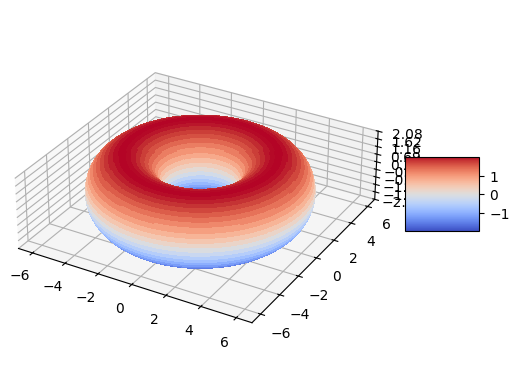

[[4.         3.99194671 3.96781925 3.92771479 3.87179481]
 [4.12684784 4.11853916 4.09364658 4.05227032 3.99457701]
 [4.25318491 4.24462187 4.21896724 4.17632432 4.11686481]
 [4.37850249 4.36968715 4.34327662 4.29937724 4.2381658 ]
 [4.50229597 4.4932314  4.46607416 4.42093362 4.35799154]]


In [ ]:
# R value is radius of larger circle
big_r = 4

# r value is radius of smaller circle
r = 2

x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
i, j = np.meshgrid(x_vals, y_vals)

phi = np.linspace(0, 2 * np.pi, 100)
theta = np.linspace(0, 2* np.pi, 100)
PHI, THETA = np.meshgrid(phi, theta)
X = (big_r + r * np.sin(THETA))*np.cos(PHI)
Y = (big_r + r * np.sin(THETA))*np.sin(PHI)
Z = r * np.cos(THETA)

# Generate graph
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
# Plot the surface.
#This is usfeful for visualisation, but really we have just supplied the points along the surface of the torus.
surf = ax.plot_surface(X, Y, Z, cmap=cm.coolwarm,
                       linewidth=0, antialiased=False)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(10))
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.02f}')

#set equal aspect ratio
ax.set_aspect('equal')

# Add a color bar which maps values to colors.
fig.colorbar(surf, shrink=0.5, aspect=1)

plt.show()


In [27]:
x_vals = np.linspace(-7,7,200)
y_vals = np.linspace(-7, 7, 200)
z_vals = np.linspace(-7, 7, 200)  #can change number of 'layers' of 2D images to simuate number of slices taken
i, j, k = np.meshgrid(x_vals, y_vals, z_vals)

#create 3d intensity array
torus_image = (np.sqrt((np.sqrt(i**2 + j**2)-big_r)**2 + k**2)<r).astype(float) #astype(float) evaluates boolean expresion with 1 or 0

viewer = napari.Viewer()
viewer.add_image(torus_image, name='torus_image')
napari.run()

# Discussion of sinograms 
Constructed from 2d intensity slices through object. 3D image reconstructed from the stacking of reconstructed 2d mages. These 2D images are reconstructed using different methods to inverse the sinogram

The Fourier Slice Theorem says:

The 1D Fourier transform of a projection equals a slice through the 2D Fourier transform of the image.

This is the key tomography theorem.

Expand on this above statement. (AI written so need to rewrite).

When reconstructing, the fourier slice theorem is basically taking the intensity projections at different angles, and for each angle it is converting the intensity distribution into a frequency distribution. All of thse fourier slices need to be combined and then the inverse found to reconstruct the image. the way the slices are combined depends on the algorithm?

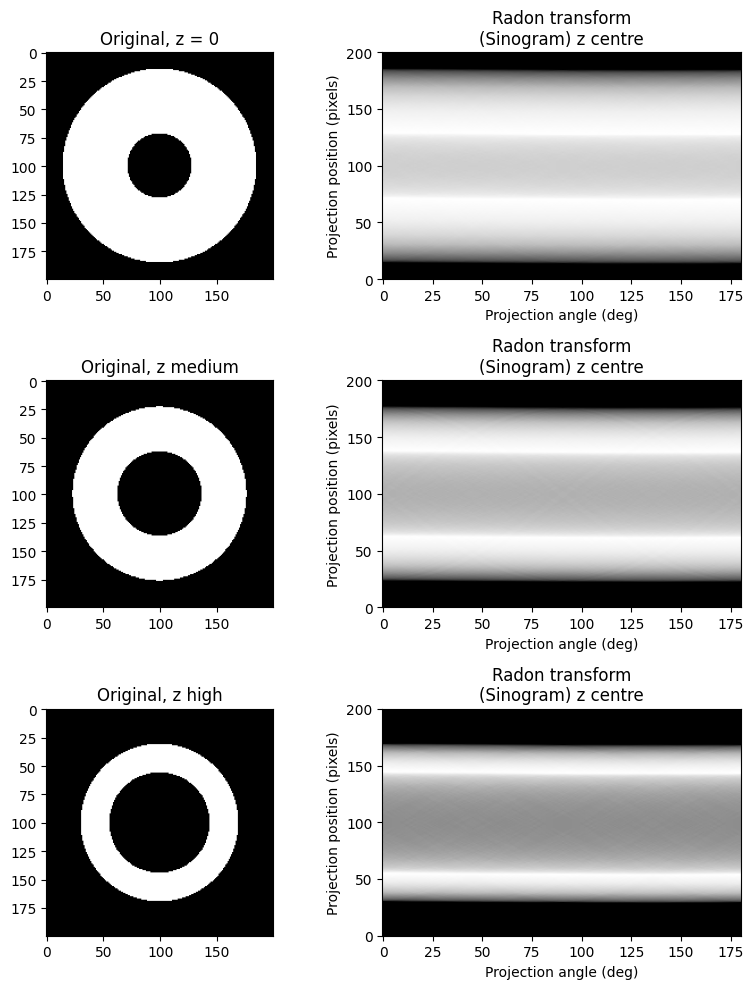

In [ ]:
# Using the radon trasnform. We will start off with a full 180 degree scan of the torus, creating a detailed sinogram

#Use central slice of torus along x-y plane with z = 0
image1 = torus_image[:,:,100]
image2 = torus_image[:,:,120]
image3 = torus_image[:,:,125]
# image = rescale(image, scale=0.2, mode='reflect', channel_axis=None)

fig, ((ax1, ax2), 
      (ax3, ax4),
      (ax5, ax6)) = plt.subplots(3, 2, figsize=(8, 10))

ax1.set_title("Original, z = 0")
ax1.imshow(image1, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, max(image1.shape), endpoint=False)
#Creates sinogram (radon transform used to simulate tomography)
sinogram = radon(image1, theta=theta)
dx, dy = 0.5 * 180.0 / max(image1.shape), 0.5 / sinogram.shape[0]
ax2.set_title("Radon transform\n(Sinogram) z centre")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)

ax3.set_title("Original, z medium")
ax3.imshow(image2, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, max(image2.shape), endpoint=False)
#Creates sinogram (radon transform used to simulate tomography)
sinogram = radon(image2, theta=theta)
dx, dy = 0.5 * 180.0 / max(image2.shape), 0.5 / sinogram.shape[0]
ax4.set_title("Radon transform\n(Sinogram) z centre")
ax4.set_xlabel("Projection angle (deg)")
ax4.set_ylabel("Projection position (pixels)")
ax4.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)


ax5.set_title("Original, z high")
ax5.imshow(image3, cmap=plt.cm.Greys_r)

theta = np.linspace(0.0, 180.0, max(image3.shape), endpoint=False)
#Creates sinogram (radon transform used to simulate tomography)
sinogram = radon(image3, theta=theta)
dx, dy = 0.5 * 180.0 / max(image3.shape), 0.5 / sinogram.shape[0]
ax6.set_title("Radon transform\n(Sinogram) z centre")
ax6.set_xlabel("Projection angle (deg)")
ax6.set_ylabel("Projection position (pixels)")
ax6.imshow(
    sinogram,
    cmap=plt.cm.Greys_r,
    extent=(-dx, 180.0 + dx, -dy, sinogram.shape[0] + dy),
    aspect='auto',
)

fig.tight_layout()
plt.show()

# How errors arise in FBP
Hard to compute inverse radon transform, the algorithms are approximations of the true inverse. There are also errors due to the rotation of the immage arrays and the interpolation used to fit rotated values tointeger grid points.

FBP rms reconstruction error: 0.0387


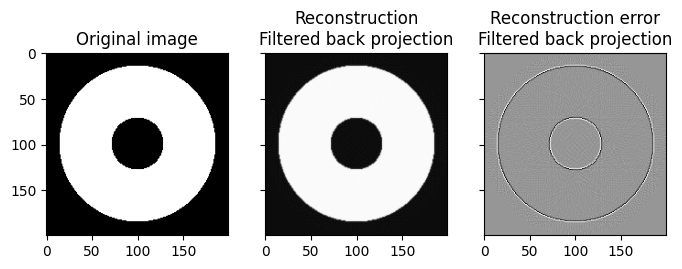

In [47]:
# Displaying reconstructed image along with error -code modified from  scikit-image radon function examples
image = torus_image[:,:,100]
sinogram = radon(image, theta=theta)

reconstruction_fbp = iradon(sinogram, theta=theta, filter_name='ramp')
error = reconstruction_fbp - image
print(f'FBP rms reconstruction error: {np.sqrt(np.mean(error**2)):.3g}')

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4.5), sharex=True, sharey=True)
ax1.set_title("Original image")
ax1.imshow(image, cmap=plt.cm.Greys_r)
ax2.set_title("Reconstruction\nFiltered back projection")
ax2.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
ax3.set_title("Reconstruction error\nFiltered back projection")
ax3.imshow(reconstruction_fbp - image, cmap=plt.cm.Greys_r, **imkwargs)
plt.show()


SART (1 iteration) rms reconstruction error: 0.0453
SART (2 iterations) rms reconstruction error: 0.0377
SART (10 iterations) rms reconstruction error: 0.0293


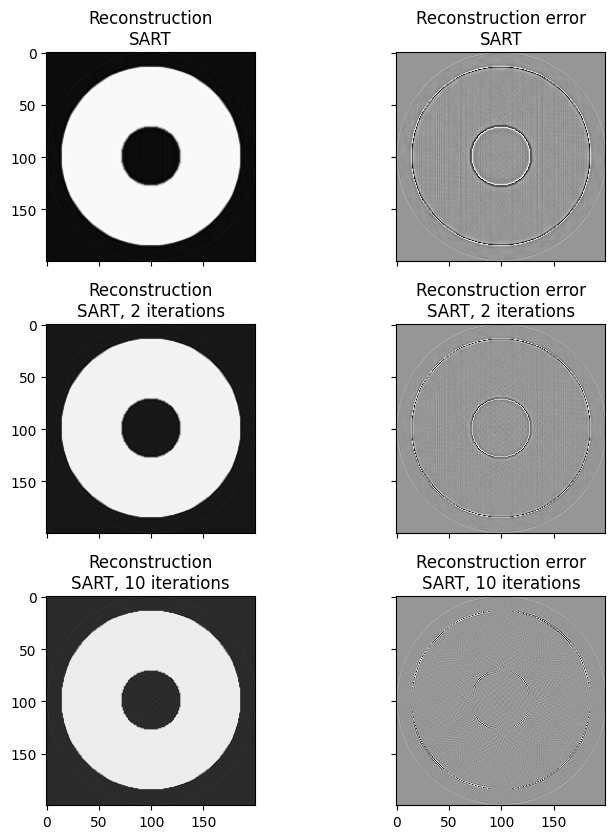

In [51]:
# XCode from scikit imag radon examples
image = torus_image[:,:,100]
sinogram = radon(image, theta=theta)

reconstruction_sart = iradon_sart(sinogram, theta=theta)
error = reconstruction_sart - image
print(
    f'SART (1 iteration) rms reconstruction error: ' f'{np.sqrt(np.mean(error**2)):.3g}'
)

fig, axes = plt.subplots(3, 2, figsize=(8, 8.5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].set_title("Reconstruction\nSART")
ax[0].imshow(reconstruction_sart, cmap=plt.cm.Greys_r)

ax[1].set_title("Reconstruction error\nSART")
ax[1].imshow(reconstruction_sart - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a second iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart2 = iradon_sart(sinogram, theta=theta, image=reconstruction_sart)
error = reconstruction_sart2 - image
print(
    f'SART (2 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)

ax[2].set_title("Reconstruction\nSART, 2 iterations")
ax[2].imshow(reconstruction_sart2, cmap=plt.cm.Greys_r)

ax[3].set_title("Reconstruction error\nSART, 2 iterations")
ax[3].imshow(reconstruction_sart2 - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a tenth iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart_n = reconstruction_sart
for i in range(9):
    reconstruction_sart_n = iradon_sart(sinogram, theta=theta, image=reconstruction_sart_n)

error = reconstruction_sart_n - image
print(
    f'SART (10 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)

ax[4].set_title("Reconstruction\nSART, 10 iterations")
ax[4].imshow(reconstruction_sart_n, cmap=plt.cm.Greys_r)

ax[5].set_title("Reconstruction error\nSART, 10 iterations")
ax[5].imshow(reconstruction_sart_n - image, cmap=plt.cm.Greys_r, **imkwargs)

fig.tight_layout()
plt.show()

# Reconstruct sparse sinogram using inverse reconstruction techniques

Notice that SART error increases as it starts fitting artefacts. Mention this

FBP rms reconstruction error: 0.699


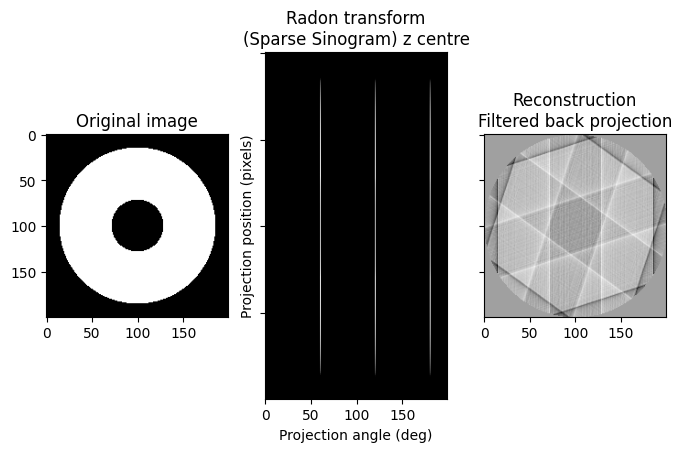

SART (1 iteration) rms reconstruction error: 0.71
SART (2 iterations) rms reconstruction error: 0.71
SART (10 iterations) rms reconstruction error: 0.712


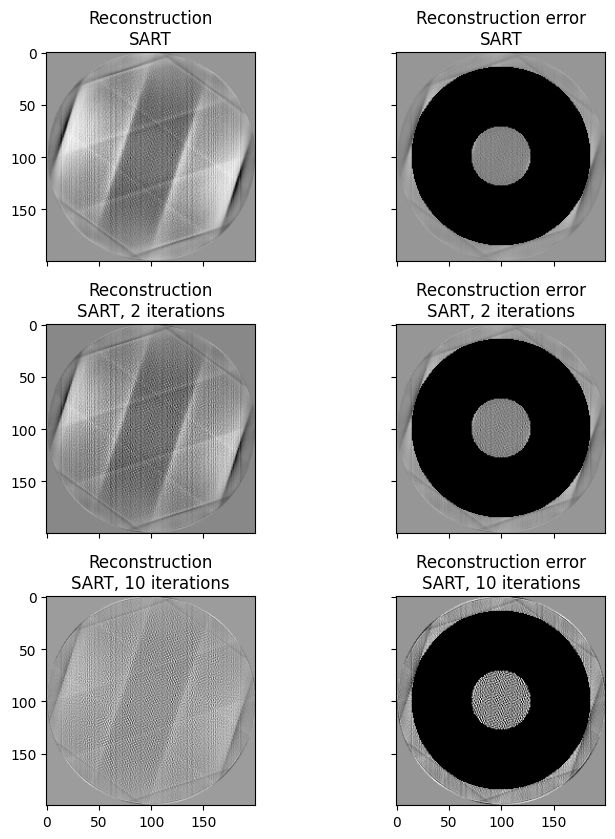

In [66]:
sparse_sinogram = np.zeros(sinogram.shape)
for i in range(len(sinogram)-1):
    if i%60 == 0:
        sparse_sinogram[:, i] = sinogram[:, i]

reconstruction_fbp = iradon(sparse_sinogram, theta=theta, filter_name='ramp')
error = reconstruction_fbp - image
print(f'FBP rms reconstruction error: {np.sqrt(np.mean(error**2)):.3g}')

imkwargs = dict(vmin=-0.2, vmax=0.2)
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(8, 4.5), sharex=True, sharey=True)
ax1.set_title("Original image")
ax1.imshow(image, cmap=plt.cm.Greys_r)
dx, dy = 0.5 * 180.0 / max(image.shape), 0.5 / sparse_sinogram.shape[0]
ax2.set_title("Radon transform\n(Sparse Sinogram) z centre")
ax2.set_xlabel("Projection angle (deg)")
ax2.set_ylabel("Projection position (pixels)")
ax2.imshow(
    sparse_sinogram,
    cmap=plt.cm.Greys_r,
    # extent=(-dx, 180.0 + dx, -dy, sparse_sinogram.shape[0] + dy),
    aspect='auto',
)
ax3.set_title("Reconstruction\nFiltered back projection")
ax3.imshow(reconstruction_fbp, cmap=plt.cm.Greys_r)
plt.show()

reconstruction_sart = iradon_sart(sparse_sinogram, theta=theta)
error = reconstruction_sart - image
print(
    f'SART (1 iteration) rms reconstruction error: ' f'{np.sqrt(np.mean(error**2)):.3g}'
)

fig, axes = plt.subplots(3, 2, figsize=(8, 8.5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].set_title("Reconstruction\nSART")
ax[0].imshow(reconstruction_sart, cmap=plt.cm.Greys_r)

ax[1].set_title("Reconstruction error\nSART")
ax[1].imshow(reconstruction_sart - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a second iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart2 = iradon_sart(sparse_sinogram, theta=theta, image=reconstruction_sart)
error = reconstruction_sart2 - image
print(
    f'SART (2 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)

ax[2].set_title("Reconstruction\nSART, 2 iterations")
ax[2].imshow(reconstruction_sart2, cmap=plt.cm.Greys_r)

ax[3].set_title("Reconstruction error\nSART, 2 iterations")
ax[3].imshow(reconstruction_sart2 - image, cmap=plt.cm.Greys_r, **imkwargs)

# Run a tenth iteration of SART by supplying the reconstruction
# from the first iteration as an initial estimate
reconstruction_sart_n = reconstruction_sart
for i in range(9):
    reconstruction_sart_n = iradon_sart(sparse_sinogram, theta=theta, image=reconstruction_sart_n)

error = reconstruction_sart_n - image
print(
    f'SART (10 iterations) rms reconstruction error: '
    f'{np.sqrt(np.mean(error**2)):.3g}'
)

ax[4].set_title("Reconstruction\nSART, 10 iterations")
ax[4].imshow(reconstruction_sart_n, cmap=plt.cm.Greys_r)

ax[5].set_title("Reconstruction error\nSART, 10 iterations")
ax[5].imshow(reconstruction_sart_n - image, cmap=plt.cm.Greys_r, **imkwargs)

fig.tight_layout()
plt.show()
       